In [30]:
%load_ext autoreload
%autoreload 2

KeyboardInterrupt: 

In [31]:
import sys

sys.path.append("..")

In [32]:
from constrerl.eval.evaluate import (
    eval_submission_concept_level_RE,
    eval_submission_mention_level_RE,
    eval_submission_NER,
    eval_submission_NERD,
)
from constrerl.erl_schema import AnnotatedArticle
import glob
from pathlib import Path
import json
import pandas as pd
from collections.abc import Callable

import re


In [33]:
results_dir = "../data/results_dev"
ground_truth_file = "../data/Annotations/Dev/json_format/dev.json"
report_dir = Path("report_dev")
results_dir = Path(results_dir)
ground_truth_file = Path(ground_truth_file)
lbl_xtra = ":tug"


top_results = 0

k_limits = [None]

with open(ground_truth_file) as f:
    ground_truth = json.load(f)

In [37]:
from re import A

from inference import AnnotationTypes


eval_results: list[dict] = []


def scoring_to_dict(
    predictions: dict, eval_f: Callable[[dict, dict], tuple[float]], gt=ground_truth
) -> dict:
    precision, recall, f1, micro_precision, micro_recall, micro_f1 = eval_f(
        predictions, gt
    )
    return {
        "$P$": precision,
        "$R$": recall,
        "$F_1$": f1,
        "$P_{micro}$": micro_precision,
        "$R_{micro}$": micro_recall,
        "$F_{1,micro}$": micro_f1,
    }


finetune_names = [
    AnnotationTypes.ENTITY,
    AnnotationTypes.RELATION,
]


def scoring_to_df(
    eval_f: Callable[[str | Path, dict], tuple[float]],
    key: str,
    res_dir=results_dir,
    k_limits_set=None,
    cap_gt=False,
    typ: AnnotationTypes | None = None,
) -> pd.DataFrame:
    eval_results: list[dict] = []
    merge_mode = "merge" in str(res_dir)
    further_mode = False  # not (("old" in str(res_dir)) or ("merge" in str(res_dir)))
    print(f"Further mode: {further_mode}")
    files = res_dir.glob("*.json")
    if not res_dir.is_dir():
        files = [res_dir]
    for result_file in files:
        set_mode = False
        result_file = Path(result_file)
        if typ is not None and (typ.value not in result_file.name):
            if "base" not in result_file.name:
                continue

        print(
            "Considering file:",
            result_file,
            "with k limits:",
            k_limits_set,
            "for finetune type:",
            typ,
        )
        try:
            with open(result_file, "r", encoding="utf-8") as file:
                predictions: dict = json.load(file)
        except OSError:
            raise OSError(f"Error in opening the specified json file: {result_file}")

        if k_limits_set is None or len(k_limits_set) == 0:
            k_list = [None]
        else:
            k_list = k_limits_set
        for k in k_list:
            predictions_limited = predictions.copy()
            predictions_limited = {
                id: {key: predictions_limited[id][key][:k]}
                for id in predictions_limited.keys()
            }
            k_gt: dict = ground_truth.copy()
            if cap_gt:
                k_gt = {id: {key: k_gt[id][key][:k]} for id in k_gt.keys()}
            if "union" in result_file.name or "intersection" in result_file.name:
                set_mode = True
            set_op = "$\cup$" if "union" in result_file.name else "$\cap$"
            eval_result = scoring_to_dict(predictions_limited, eval_f, gt=k_gt)
            model_name = "3.2 1B" if "hermes-3-2-3B" in result_file.name else "3.1 8B"
            if "eval_naive" in result_file.name:
                model_name = "Naive"
            # splits = model_name.split(" ")
            # if len(splits) > 2:
            #     model_name = splits[0] + " " + "-".join(splits[1:])
            is_lora = any(
                t.value in result_file.name for t in finetune_names
            ) and not result_file.name.startswith("eval_naive")
            def beam_type(name: str) -> str:
                if "beam-end" in name:
                    return "End"
                elif "beam-shallow" in name:
                    return "Shallow"
                else:
                    return "$\\times$"
            result_dict = {
                "Model": model_name,
                "NE FT": "\checkmark" if "neefinetuned" in result_file.name else "$\\times$",
                "Beams": beam_type(result_file.name),
                "Naive": "\checkmark" if "naive" in result_file.name else "$\\times$",
                "Filter": "\checkmark"
                if "filtered" in result_file.name
                else "$\\times$",
                "RAG": "\checkmark" if "rag" in result_file.name else "$\\times$",
                # "Long $t$": "\checkmark" if "long" in result_file.name else "$\\times$",
                "LoRA": "\checkmark" if is_lora else "$\\times$",
            }
            if k is not None:
                result_dict["$k$"] = k
            if set_mode:
                result_dict["Set"] = set_op
            result_dict.update(eval_result)
            # result_dict.update({f"6_2_2_{k}": v for k, v in ternary_tag_score.items()})
            # result_dict.update({f"6_2_3_{k}": v for k, v in ternary_mention_score.items()})
            eval_results.append(result_dict)
    eval_df = pd.DataFrame(eval_results)
    # if further_mode and "$k$" not in eval_df.columns:
    #     eval_df = eval_df[(eval_df["Long $t$"] == "\checkmark")]
    # if merge_mode:
    #     eval_df = eval_df[eval_df["Model"].str.contains("Hermes 3B")]
    valid_cols = [
        c
        for c in [
            "Model",
            "Beams",
            "NE FT",
            "RAG",
            "LoRA",
            "Naive",
            "Filter",
        ]
        if c in eval_df.columns
    ]
    eval_df.set_index(valid_cols, inplace=True)
    eval_df = eval_df.sort_index()
    # if "$F_{1,micro}$" in eval_df.columns:
    #     eval_df = eval_df.sort_values("$F_{1,micro}$")
    return eval_df


task_6_1_1_df = scoring_to_df(
    eval_submission_NER, "entities", typ=AnnotationTypes.ENTITY
)
task_6_1_2_df = scoring_to_df(
    eval_submission_NERD, "entities", typ=AnnotationTypes.ENTITY
)
task_6_2_1_df = scoring_to_df(
    eval_submission_mention_level_RE,
    "mention_level_relations",
    typ=AnnotationTypes.RELATION,
)
task_6_2_2_df = scoring_to_df(
    eval_submission_concept_level_RE,
    "concept_level_relations",
    typ=AnnotationTypes.RELATION,
)

<>:82: SyntaxWarning: invalid escape sequence '\c'
<>:82: SyntaxWarning: invalid escape sequence '\c'
<>:102: SyntaxWarning: invalid escape sequence '\c'
<>:104: SyntaxWarning: invalid escape sequence '\c'
<>:105: SyntaxWarning: invalid escape sequence '\c'
<>:108: SyntaxWarning: invalid escape sequence '\c'
<>:110: SyntaxWarning: invalid escape sequence '\c'
<>:82: SyntaxWarning: invalid escape sequence '\c'
<>:82: SyntaxWarning: invalid escape sequence '\c'
<>:102: SyntaxWarning: invalid escape sequence '\c'
<>:104: SyntaxWarning: invalid escape sequence '\c'
<>:105: SyntaxWarning: invalid escape sequence '\c'
<>:108: SyntaxWarning: invalid escape sequence '\c'
<>:110: SyntaxWarning: invalid escape sequence '\c'
/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_20048/3548543151.py:82: SyntaxWarning: invalid escape sequence '\c'
  set_op = "$\cup$" if "union" in result_file.name else "$\cap$"
/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_20048/3548543151.py:82: S

Further mode: False
Considering file: ../data/results_dev/eval_naive-entities.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 6476 duplicated entities from predictions ===
=== Removed 4145 overlapping entities ===
Considering file: ../data/results_dev/eval_hermes_neefinetuned-rag-lora-entities-naive-beam-none-hermes-3-2-3B-entities.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 6598 duplicated entities from predictions ===
=== Removed 5610 overlapping entities ===
Considering file: ../data/results_dev/eval_hermes-rag-beam-none-hermes-3-2-3B-base.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 35 duplicated entities from predictions ===
Considering file: ../data/results_dev/eval_hermes-rag-beam-none-hermes-3-1-8B-base.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 15 duplicated entities from predictions ===
=== Removed 2 overlapping entities ===
Considering file:

In [38]:
task_6_1_1_df = scoring_to_df(eval_submission_NER, "entities", typ=AnnotationTypes.ENTITY)
task_6_1_1_df

Further mode: False
Considering file: ../data/results_dev/eval_naive-entities.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 6476 duplicated entities from predictions ===
=== Removed 4145 overlapping entities ===
Considering file: ../data/results_dev/eval_hermes_neefinetuned-rag-lora-entities-naive-beam-none-hermes-3-2-3B-entities.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 6598 duplicated entities from predictions ===
=== Removed 5610 overlapping entities ===
Considering file: ../data/results_dev/eval_hermes-rag-beam-none-hermes-3-2-3B-base.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 35 duplicated entities from predictions ===
Considering file: ../data/results_dev/eval_hermes-rag-beam-none-hermes-3-1-8B-base.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 15 duplicated entities from predictions ===
=== Removed 2 overlapping entities ===
Considering file:

$P$  \
Model  Beams    NE FT      RAG        LoRA       Naive      Filter                 
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.103826   
                                                 \checkmark $\times$    0.428541   
                                      \checkmark $\times$   $\times$    0.316348   
                                                 \checkmark $\times$    0.436229   
                           \checkmark $\times$   $\times$   $\times$    0.439343   
                                                 \checkmark $\times$    0.461237   
                                      \checkmark $\times$   $\times$    0.360958   
                                                 \checkmark $\times$    0.468399   
                \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.485546   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.483859   
                           \checkmark $\times$   $\times$   $\times$    0.000052   
                                                 \checkmark $\times$    0.476240   
                                      \checkmark $\times$   $\times$    0.000084   
                                                 \checkmark $\times$    0.495963   
       End      \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                           \checkmark $\times$   \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
3.2 1B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.126060   
                                                 \checkmark $\times$    0.448207   
                                      \checkmark $\times$   $\times$    0.136490   
                                                 \checkmark $\times$    0.473553   
                           \checkmark $\times$   $\times$   $\times$    0.311033   
                                                 \checkmark $\times$    0.452317   
                                      \checkmark $\times$   $\times$    0.348357   
                                                 \checkmark $\times$    0.479939   
                \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.490206   
                                      \checkmark $\times$   $\times$    0.000081   
                                                 \checkmark $\times$    0.496756   
                           \checkmark $\times$   $\times$   $\times$    0.000106   
                                                 \checkmark $\times$    0.484257   
                                      \checkmark $\times$   $\times$    0.000085   
                                                 \checkmark $\times$    0.486980   
       End      \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                           \checkmark $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                             

In [39]:
task_6_1_1_df[top_results:].style.highlight_max(axis=0, props="textbf:--rwrap;").format(precision=2).to_latex(
    report_dir / "task_6_1_1.tex",
    # float_format="%.2f",
    caption="Dev Set Result for Task 6.1.1 (NER) for various models and approaches.",
    label=f"tab:task:6_1_1{lbl_xtra}",
    clines="all;data",
    hrules=True
)
task_6_1_1_df

$P$  \
Model  Beams    NE FT      RAG        LoRA       Naive      Filter                 
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.103826   
                                                 \checkmark $\times$    0.428541   
                                      \checkmark $\times$   $\times$    0.316348   
                                                 \checkmark $\times$    0.436229   
                           \checkmark $\times$   $\times$   $\times$    0.439343   
                                                 \checkmark $\times$    0.461237   
                                      \checkmark $\times$   $\times$    0.360958   
                                                 \checkmark $\times$    0.468399   
                \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.485546   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.483859   
                           \checkmark $\times$   $\times$   $\times$    0.000052   
                                                 \checkmark $\times$    0.476240   
                                      \checkmark $\times$   $\times$    0.000084   
                                                 \checkmark $\times$    0.495963   
       End      \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                           \checkmark $\times$   \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
3.2 1B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.126060   
                                                 \checkmark $\times$    0.448207   
                                      \checkmark $\times$   $\times$    0.136490   
                                                 \checkmark $\times$    0.473553   
                           \checkmark $\times$   $\times$   $\times$    0.311033   
                                                 \checkmark $\times$    0.452317   
                                      \checkmark $\times$   $\times$    0.348357   
                                                 \checkmark $\times$    0.479939   
                \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.490206   
                                      \checkmark $\times$   $\times$    0.000081   
                                                 \checkmark $\times$    0.496756   
                           \checkmark $\times$   $\times$   $\times$    0.000106   
                                                 \checkmark $\times$    0.484257   
                                      \checkmark $\times$   $\times$    0.000085   
                                                 \checkmark $\times$    0.486980   
       End      \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                           \checkmark $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                             

In [40]:
task_6_1_2_df = scoring_to_df(eval_submission_NERD, "entities", typ=AnnotationTypes.ENTITY)
task_6_1_2_df

Further mode: False
Considering file: ../data/results_dev/eval_naive-entities.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 6476 duplicated entities from predictions ===
=== Removed 4145 overlapping entities ===
Considering file: ../data/results_dev/eval_hermes_neefinetuned-rag-lora-entities-naive-beam-none-hermes-3-2-3B-entities.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 6598 duplicated entities from predictions ===
=== Removed 5610 overlapping entities ===
Considering file: ../data/results_dev/eval_hermes-rag-beam-none-hermes-3-2-3B-base.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 35 duplicated entities from predictions ===
Considering file: ../data/results_dev/eval_hermes-rag-beam-none-hermes-3-1-8B-base.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 15 duplicated entities from predictions ===
=== Removed 2 overlapping entities ===
Considering file:

$P$  \
Model  Beams    NE FT      RAG        LoRA       Naive      Filter                 
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.065726   
                                                 \checkmark $\times$    0.366110   
                                      \checkmark $\times$   $\times$    0.207104   
                                                 \checkmark $\times$    0.369652   
                           \checkmark $\times$   $\times$   $\times$    0.323692   
                                                 \checkmark $\times$    0.380369   
                                      \checkmark $\times$   $\times$    0.176646   
                                                 \checkmark $\times$    0.394000   
                \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.421718   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.422666   
                           \checkmark $\times$   $\times$   $\times$    0.000052   
                                                 \checkmark $\times$    0.411370   
                                      \checkmark $\times$   $\times$    0.000084   
                                                 \checkmark $\times$    0.431016   
       End      \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                           \checkmark $\times$   \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
3.2 1B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.041417   
                                                 \checkmark $\times$    0.381353   
                                      \checkmark $\times$   $\times$    0.093524   
                                                 \checkmark $\times$    0.396645   
                           \checkmark $\times$   $\times$   $\times$    0.231907   
                                                 \checkmark $\times$    0.377087   
                                      \checkmark $\times$   $\times$    0.243563   
                                                 \checkmark $\times$    0.410278   
                \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.429761   
                                      \checkmark $\times$   $\times$    0.000081   
                                                 \checkmark $\times$    0.430451   
                           \checkmark $\times$   $\times$   $\times$    0.000106   
                                                 \checkmark $\times$    0.417889   
                                      \checkmark $\times$   $\times$    0.000085   
                                                 \checkmark $\times$    0.428786   
       End      \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                           \checkmark $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                             

In [41]:
task_6_1_2_df[top_results:].style.highlight_max(axis=0, props="textbf:--rwrap;").format(precision=2).to_latex(
    report_dir / "task_6_1_2.tex",
    # float_format="%.2f",
    caption="Dev Set Result for Task 6.1.2 (NERD) for various models and approaches.",
    label=f"tab:task:6_1_2{lbl_xtra}",
    clines="all;data",
    hrules=True
)
task_6_1_2_df

$P$  \
Model  Beams    NE FT      RAG        LoRA       Naive      Filter                 
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.065726   
                                                 \checkmark $\times$    0.366110   
                                      \checkmark $\times$   $\times$    0.207104   
                                                 \checkmark $\times$    0.369652   
                           \checkmark $\times$   $\times$   $\times$    0.323692   
                                                 \checkmark $\times$    0.380369   
                                      \checkmark $\times$   $\times$    0.176646   
                                                 \checkmark $\times$    0.394000   
                \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.421718   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.422666   
                           \checkmark $\times$   $\times$   $\times$    0.000052   
                                                 \checkmark $\times$    0.411370   
                                      \checkmark $\times$   $\times$    0.000084   
                                                 \checkmark $\times$    0.431016   
       End      \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                           \checkmark $\times$   \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
3.2 1B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.041417   
                                                 \checkmark $\times$    0.381353   
                                      \checkmark $\times$   $\times$    0.093524   
                                                 \checkmark $\times$    0.396645   
                           \checkmark $\times$   $\times$   $\times$    0.231907   
                                                 \checkmark $\times$    0.377087   
                                      \checkmark $\times$   $\times$    0.243563   
                                                 \checkmark $\times$    0.410278   
                \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.429761   
                                      \checkmark $\times$   $\times$    0.000081   
                                                 \checkmark $\times$    0.430451   
                           \checkmark $\times$   $\times$   $\times$    0.000106   
                                                 \checkmark $\times$    0.417889   
                                      \checkmark $\times$   $\times$    0.000085   
                                                 \checkmark $\times$    0.428786   
       End      \checkmark $\times$   $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                           \checkmark $\times$   $\times$   $\times$    0.000000   
                                                 \checkmark $\times$    0.000000   
                                      \checkmark $\times$   $\times$    0.000000   
                                             

In [42]:
task_6_2_1_df

$P$  \
Model  Beams    NE FT      RAG        LoRA       Naive      Filter               
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$  0.003186   
                                                 \checkmark $\times$  0.004146   
                                      \checkmark $\times$   $\times$  0.071186   
                                                 \checkmark $\times$  0.067512   
                           \checkmark $\times$   $\times$   $\times$  0.047363   
                                                 \checkmark $\times$  0.047363   
                                      \checkmark $\times$   $\times$  0.044177   
                                                 \checkmark $\times$  0.044177   
                \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                           \checkmark $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
       End      \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                           \checkmark $\times$   \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
3.2 1B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$  0.000060   
                                                 \checkmark $\times$  0.000060   
                                      \checkmark $\times$   $\times$  0.035340   
                                                 \checkmark $\times$  0.033528   
                           \checkmark $\times$   $\times$   $\times$  0.040171   
                                                 \checkmark $\times$  0.040171   
                                      \checkmark $\times$   $\times$  0.035026   
                                                 \checkmark $\times$  0.035026   
                \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                           \checkmark $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
       End      \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                           \checkmark $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   

                                                        

In [43]:
task_6_2_1_df[top_results:].style.highlight_max(axis=0, props="textbf:--rwrap;").format(precision=2).to_latex(
    report_dir / "task_6_2_1.tex",
    # float_format="%.2f",
    caption="Dev Set Result for Task 6.2.1 for various models and approaches.",
    label=f"tab:task:6_2_1{lbl_xtra}",
    clines="all;data",
    hrules=True
)
task_6_2_1_df

$P$  \
Model  Beams    NE FT      RAG        LoRA       Naive      Filter               
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$  0.003186   
                                                 \checkmark $\times$  0.004146   
                                      \checkmark $\times$   $\times$  0.071186   
                                                 \checkmark $\times$  0.067512   
                           \checkmark $\times$   $\times$   $\times$  0.047363   
                                                 \checkmark $\times$  0.047363   
                                      \checkmark $\times$   $\times$  0.044177   
                                                 \checkmark $\times$  0.044177   
                \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                           \checkmark $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
       End      \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                           \checkmark $\times$   \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
3.2 1B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$  0.000060   
                                                 \checkmark $\times$  0.000060   
                                      \checkmark $\times$   $\times$  0.035340   
                                                 \checkmark $\times$  0.033528   
                           \checkmark $\times$   $\times$   $\times$  0.040171   
                                                 \checkmark $\times$  0.040171   
                                      \checkmark $\times$   $\times$  0.035026   
                                                 \checkmark $\times$  0.035026   
                \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                           \checkmark $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
       End      \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                           \checkmark $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   

                                                        

In [44]:
task_6_2_2_df[top_results:].style.highlight_max(axis=0, props="textbf:--rwrap;").format(precision=2).to_latex(
    report_dir / "task_6_2_2.tex",
    # float_format="%.2f",
    caption="Further Dev Set Result for Task 6.2.2 for various models and approaches.",
    label=f"tab:task:6_2_2{lbl_xtra}",
    clines="all;data",
    hrules=True
)
task_6_2_2_df

$P$  \
Model  Beams    NE FT      RAG        LoRA       Naive      Filter               
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$  0.005438   
                                                 \checkmark $\times$  0.017567   
                                      \checkmark $\times$   $\times$  0.060982   
                                                 \checkmark $\times$  0.058821   
                           \checkmark $\times$   $\times$   $\times$  0.072917   
                                                 \checkmark $\times$  0.072917   
                                      \checkmark $\times$   $\times$  0.043555   
                                                 \checkmark $\times$  0.043555   
                \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.006842   
                                                 \checkmark $\times$  0.006842   
                           \checkmark $\times$   $\times$   $\times$  0.007178   
                                                 \checkmark $\times$  0.007178   
                                      \checkmark $\times$   $\times$  0.005569   
                                                 \checkmark $\times$  0.005569   
       End      \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                           \checkmark $\times$   \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
3.2 1B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$  0.000088   
                                                 \checkmark $\times$  0.000088   
                                      \checkmark $\times$   $\times$  0.060919   
                                                 \checkmark $\times$  0.056601   
                           \checkmark $\times$   $\times$   $\times$  0.045404   
                                                 \checkmark $\times$  0.045404   
                                      \checkmark $\times$   $\times$  0.046230   
                                                 \checkmark $\times$  0.046230   
                \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.015576   
                                                 \checkmark $\times$  0.015576   
                           \checkmark $\times$   $\times$   $\times$  0.003116   
                                                 \checkmark $\times$  0.003116   
                                      \checkmark $\times$   $\times$  0.000598   
                                                 \checkmark $\times$  0.000598   
       End      \checkmark $\times$   $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                           \checkmark $\times$   $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   
                                      \checkmark $\times$   $\times$  0.000000   
                                                 \checkmark $\times$  0.000000   

                                                        

Further mode: False
Considering file: ../data/results_dev/eval_naive-entities.json with k limits: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202,

/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_20048/118417574.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(k_s)


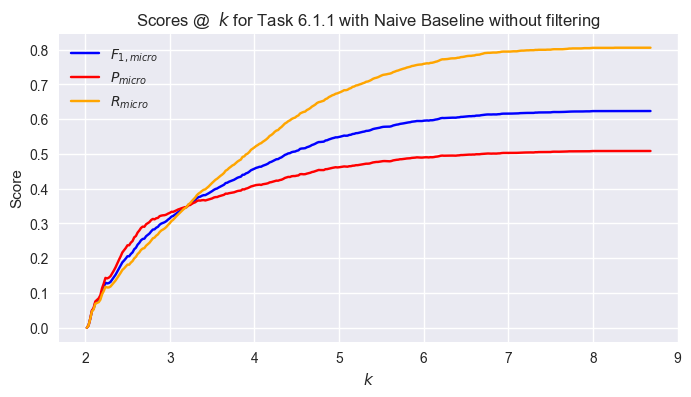

In [45]:
import colorsys

from constrerl.utils import EvalData

import matplotlib.pyplot as plt
import numpy as np
import tikzplotlib
import re

# style to sbn
plt.style.use("seaborn-v0_8")


def tikzplotlib_fix_ncols(obj):
    """
    workaround for matplotlib 3.6 renamed legend's _ncol to _ncols, which breaks tikzplotlib
    """
    if hasattr(obj, "_ncols"):
        obj._ncol = obj._ncols
    for child in obj.get_children():
        tikzplotlib_fix_ncols(child)


def vary_over_k(
    fn="eval_naive-entities.json",
    max_k: int | None = None,
    out_file="f1_at_k_ner.tex",
    score_method=eval_submission_NER,
    score_name="entities",
    title="Scores @  $k$ for Task 6.1.1 with Naive Baseline without filtering",
):
    annotated_articles: dict[str, EvalData] = {}
    with open(results_dir / fn, "r", encoding="utf-8") as file:
        predictions: dict = json.load(file)
        for k, v in predictions.items():
            annotated_articles[k] = EvalData.model_validate(v)
    if max_k is None:
        ks = []
        for id in annotated_articles.keys():
            d = annotated_articles[id]
            d_data = d.model_dump()
            k = len(d_data[score_name])
            ks.append(k)
        max_k = max(ks)
    k = list(range(1, max_k + 1))

    f_at_k = scoring_to_df(
        score_method,
        score_name,
        k_limits_set=k,
        cap_gt=True,
        res_dir=results_dir / fn,
    )
    k_s = f_at_k.reset_index()["$k$"].to_numpy()
    seriess = ["$F_{1,micro}$", "$P_{micro}$", "$R_{micro}$"]
    colors = ["blue", "red", "orange"]
    stack = np.stack([f_at_k[s].to_numpy() for s in seriess], axis=1)
    max_score = stack.max()

    fig = plt.figure(figsize=(8, 4))
    ax = fig.add_subplot(111)
    for i, s in enumerate(seriess):
        ax.plot(k_s, f_at_k[s].to_numpy(), label=s, color=colors[i])
    ax.set_ylabel("Score")
    ax.set_xlabel("$k$")
    ax.set_title(title)
    ax.legend()
    ax.set_xticklabels(k_s)
    y_tick_div = 0.1 if max_score > 0.5 else 0.05

    ax.set_yticks(np.arange(0, max_score, y_tick_div))
    tikzplotlib_fix_ncols(fig)
    tikzplotlib.save(
        report_dir / out_file,
        figure=fig,
        axis_width="0.8\\linewidth",
        axis_height="0.4\\linewidth",
        # extra_axis_parameters={
        #     "legend style": r"legend pos=outer north east",
        #     "legend columns": 1,
        #     "legend cell align": "left",
        #     "legend to name": "loss_legend",
        #     "legend entries": ["loss"],
        # },
    )


vary_over_k()

Further mode: False
Considering file: ../data/results_dev/eval_naive-entities.json with k limits: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202,

/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_20048/118417574.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(k_s)


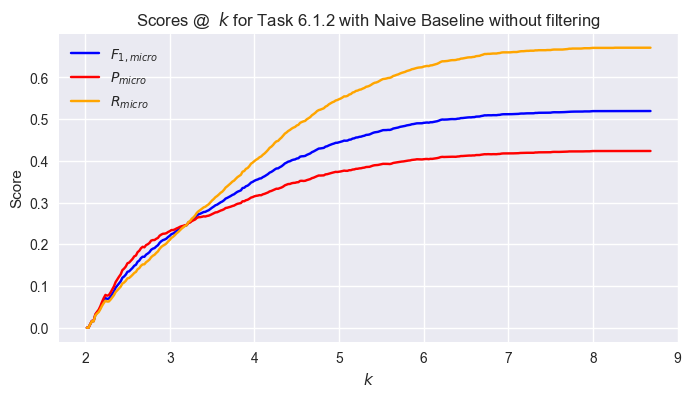

In [46]:
vary_over_k(
    fn="eval_naive-entities.json",
    max_k=None,
    out_file="f1_at_k_nerd.tex",
    score_method=eval_submission_NERD,
    score_name="entities",
    title="Scores @  $k$ for Task 6.1.2 with Naive Baseline without filtering",
)

/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_20048/118417574.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(k_s)


Further mode: False
Considering file: ../data/results_dev/eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json with k limits: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41] for finetune type: None
=== Removed 1 duplicated mention-level relations from predictions ===
=== Removed 2 duplicated mention-level relations from predictions ===
=== Removed 3 duplicated mention-level relations from predictions ===
=== Removed 4 duplicated mention-level relations from predictions ===
=== Removed 6 duplicated mention-level relations from predictions ===
=== Removed 9 duplicated mention-level relations from predictions ===
=== Removed 10 duplicated mention-level relations from predictions ===
=== Removed 11 duplicated mention-level relations from predictions ===
=== Removed 15 duplicated mention-level relations from predictions ===
=== Removed 17 duplicated

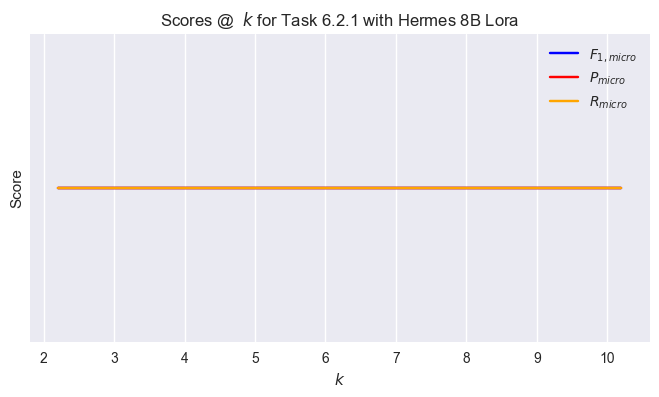

In [47]:
vary_over_k(
    fn="eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json",
    max_k=None,
    out_file="f1_at_k_re.tex",
    score_method=eval_submission_mention_level_RE,
    score_name="mention_level_relations",
    title="Scores @  $k$ for Task 6.2.1 with Hermes 8B Lora",
)

Further mode: False
Considering file: ../data/results_dev/eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json with k limits: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41] for finetune type: None
=== Removed 3 duplicated concept-level relations from predictions ===
=== Removed 12 duplicated concept-level relations from predictions ===
=== Removed 25 duplicated concept-level relations from predictions ===
=== Removed 38 duplicated concept-level relations from predictions ===
=== Removed 49 duplicated concept-level relations from predictions ===
=== Removed 68 duplicated concept-level relations from predictions ===
=== Removed 82 duplicated concept-level relations from predictions ===
=== Removed 97 duplicated concept-level relations from predictions ===
=== Removed 117 duplicated concept-level relations from predictions ===
=== Removed 138 dup

/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_20048/118417574.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(k_s)


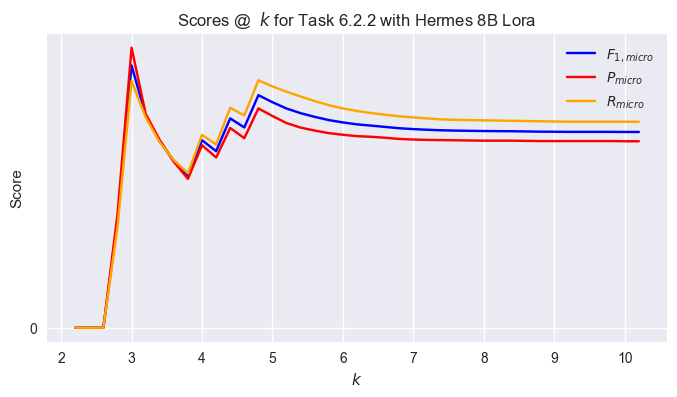

In [48]:
vary_over_k(
    fn="eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json",
    max_k=None,
    out_file="f1_at_k_red.tex",
    score_method=eval_submission_concept_level_RE,
    score_name="concept_level_relations",
    title="Scores @  $k$ for Task 6.2.2 with Hermes 8B Lora",
)